Purpose: Check if there is any correlation between sample number and number of time-structured genes for different genotypes.<br>
Author: Anna Pardo<br>
Date initiated: Dec. 2, 2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

In [3]:
plotc = pd.read_csv("./clusters_ngenes_gt_ztgroup_with36.txt",sep="\t",header="infer")
plotc.head()

,cluster,genotype,n_CAM_genes,n_all_genes,gtc,ZTpeak
0,1,53,0.0,319,53_1,5.0
1,2,53,1.0,656,53_2,21.0
2,3,53,1.0,882,53_3,17.0
3,4,53,0.0,1071,53_4,9.0
4,5,53,0.0,428,53_5,21.0


In [4]:
# load metadata (off TPM)
md = pd.read_csv("./metadata_from_TPM_ztsub.txt",sep="\t",header="infer")
md.head()

,sample_name,genotype,treat,ZT
0,Y1,18,W,1.0
1,Y101,2AB,D,1.0
2,Y103,2AB,D,1.0
3,Y104,1AB,W,21.0
4,Y105,18,W,21.0


In [7]:
md["condition"] = md["treat"]+"_"+md["ZT"].astype(str)
md.head()

,sample_name,genotype,treat,ZT,condition
0,Y1,18,W,1.0,W_1.0
1,Y101,2AB,D,1.0,D_1.0
2,Y103,2AB,D,1.0,D_1.0
3,Y104,1AB,W,21.0,W_21.0
4,Y105,18,W,21.0,W_21.0


In [32]:
# for each genotype in plotc, find the number of samples in md
## also find the mean number of reps
def find_nsamp(gt):
    gtmd = md[md["genotype"]==gt]
    nsamp = len(gtmd["sample_name"].unique())
    # to find number of reps, make a summary table on condition col
    csum = gtmd.groupby("condition").count().reset_index()[["condition","sample_name"]].rename(columns={"sample_name":"nreps"})
    if len(csum.index)>0:
        meanreps = sum(csum["nreps"])/len(csum.index)
    else:
        meanreps = 0
    return [nsamp,int(round(meanreps,0))]

In [33]:
dfdict = {"genotype":[],"n_samples":[],"mean_reps":[]}
for g in list(plotc["genotype"].unique()):
    dfdict['genotype'].append(g)
    l = find_nsamp(g)
    dfdict['n_samples'].append(l[0])
    dfdict['mean_reps'].append(l[1])
nsmr = pd.DataFrame(dfdict)

In [34]:
nsmr = nsmr[nsmr["genotype"]!="all"]

In [35]:
# add in information about the total number of time-structured genes for each genotype
def total_ts_gt(gt):
    gtinfo = plotc[plotc["genotype"]==gt]
    return sum(gtinfo["n_all_genes"])

In [36]:
total = []
for i in nsmr["genotype"].unique():
    total.append(total_ts_gt(i))
nsmr["total_ts_genes"] = total
nsmr.head()

,genotype,n_samples,mean_reps,total_ts_genes
0,53,17,2,4133
1,Eudy,25,2,8871
2,13,34,3,3890
3,52,25,2,6178
4,48,23,2,6963


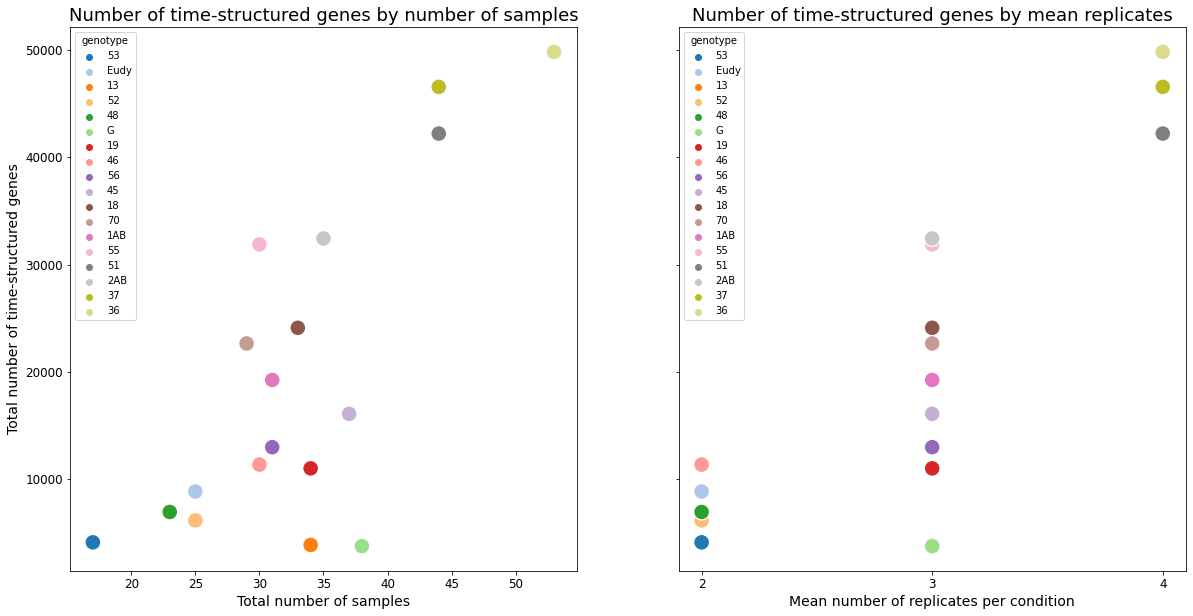

In [43]:
fig,ax = plt.subplots(nrows=1,ncols=2,figsize=(20,10),sharey=True)

sns.scatterplot(ax=ax[0],data=nsmr,y="total_ts_genes",x="n_samples",hue="genotype",palette="tab20",s=250)
ax[0].set_xlabel("Total number of samples",fontsize=14)
ax[0].set_ylabel("Total number of time-structured genes",fontsize=14)
ax[0].tick_params(axis="both",which="major",labelsize=12)
ax[0].set_title("Number of time-structured genes by number of samples",fontsize=18)

sns.scatterplot(ax=ax[1],data=nsmr,y="total_ts_genes",x="mean_reps",hue="genotype",palette="tab20",s=250)
ax[1].set_xlabel("Mean number of replicates per condition",fontsize=14)
ax[1].tick_params(axis="x",which="major",labelsize=12)
ax[1].set_xticks(np.arange(2,5,1))
ax[1].set_title("Number of time-structured genes by mean replicates",fontsize=18)

plt.savefig("./tsgenes_by_nsamp_meanreps.png",dpi=200,bbox_inches="tight")
plt.savefig("./tsgenes_by_nsamp_meanreps.pdf",dpi=200,bbox_inches="tight")
plt.savefig("./tsgenes_by_nsamp_meanreps.svg",dpi=200,bbox_inches="tight")

In [44]:
# now run the correlation - get both R & p-values
nsmr.corr("pearson")

,n_samples,mean_reps,total_ts_genes
n_samples,1.000000,0.893837,0.743170
mean_reps,0.893837,1.000000,0.807884
total_ts_genes,0.743170,0.807884,1.000000


In [45]:
def calculate_pvalues(df):
    dfcols = pd.DataFrame(columns=df.columns)
    pvalues = dfcols.transpose().join(dfcols, how='outer')
    for r in df.columns:
        for c in df.columns:
            tmp = df[df[r].notnull() & df[c].notnull()]
            pvalues[r][c] = round(pearsonr(tmp[r], tmp[c])[1], 4)
    return pvalues

In [46]:
calculate_pvalues(nsmr[["total_ts_genes","n_samples","mean_reps"]])

,total_ts_genes,n_samples,mean_reps
total_ts_genes,0.0,0.0004,0.0001
n_samples,0.0004,0.0,0.0
mean_reps,0.0001,0.0,0.0
